In [2]:
from networkx.readwrite import json_graph
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
with open("rfa_graph.json", "r", encoding="utf-8") as f:
    data = json.load(f)

G = json_graph.node_link_graph(data)

In [4]:
print(type(G))
print(G.number_of_nodes(), G.number_of_edges())
print(list(G.nodes(data=True))[:10])
print(list(G.edges(data=True))[:10])

<class 'networkx.classes.multidigraph.MultiDiGraph'>
11381 198275
[('Steel1943', {}), ('BDD', {}), ('Cuchullain', {}), ('INeverCry', {}), ('Cncmaster', {}), ('Miniapolis', {}), ('Sven Manguard', {}), ('Ramaksoud2000', {}), ('RockMagnetist', {}), ('Carrite', {})]
[('Steel1943', 'BDD', {'vote': 1, 'text': "'''Support''' as co-nom.", 'result': 1, 'year': 2013, 'date': '23:13, 19 April 2013'}), ('Steel1943', 'RockMagnetist', {'vote': 0, 'text': '<del>\'\'\'Neutral\'\'\'</del>. \'\'\'Moral Support\'\'\'. I\'ve only run across RockMagnetist once in my travels in checking/editing articles on this Wikipedia, and RockMagnetist seems like a good candidate for this based on the description above. However, since I have to base my votes on the actual experience I have had with the user as an editor, I cannot sway my vote either way. Either way, I am leaning more towards a support, but since I vote based on interaction, I have neither any positive nor negative thoughts going through my head, so I vo

In [5]:
from collections import defaultdict

votes_by_candidate = defaultdict(list)

for u, v, data in G.edges(data=True):
    vote = data.get("vote")
    
    if vote == 0:
        continue  # skip neutral votes

    votes_by_candidate[v].append((u, vote))

print("Number of candidates:", len(votes_by_candidate))

# inspect a few
for i, (cand, voters) in enumerate(votes_by_candidate.items()):
    print(cand, voters[:5])
    if i == 3:
        break

Number of candidates: 3494
BDD [('Steel1943', 1), ('Cuchullain', 1), ('INeverCry', 1), ('Cncmaster', 1), ('Miniapolis', 1)]
Jasper Deng [('Steel1943', -1), ('Miniapolis', 1), ('Secret', 1), ('Dennis Brown', 1), ('King of Hearts', 1)]
Miniapolis [('BDD', 1), ('INeverCry', 1), ('Carrite', 1), ('Someguy1221', 1), ('Secret', 1)]
West.andrew.g [('BDD', 1), ('INeverCry', 1), ('Cncmaster', 1), ('Miniapolis', 1), ('Carrite', 1)]


In [6]:
from itertools import combinations

G_proj = nx.Graph()

for cand, voter_list in votes_by_candidate.items():
    for (u, vote_u), (v, vote_v) in combinations(voter_list, 2):
        pair_weight = vote_u * vote_v   # +1 agreement, -1 disagreement

        if G_proj.has_edge(u, v):
            G_proj[u][v]["weight"] += pair_weight
            G_proj[u][v]["count"] += 1
        else:
            G_proj.add_edge(u, v, weight=pair_weight, count=1)

print("Projected graph:")
print("Nodes:", G_proj.number_of_nodes())
print("Edges:", G_proj.number_of_edges())

print(list(G_proj.edges(data=True))[:10])

Projected graph:
Nodes: 10284
Edges: 3062358
[('Steel1943', 'Cuchullain', {'weight': 1, 'count': 1}), ('Steel1943', 'INeverCry', {'weight': 1, 'count': 1}), ('Steel1943', 'Cncmaster', {'weight': 1, 'count': 1}), ('Steel1943', 'Miniapolis', {'weight': 0, 'count': 2}), ('Steel1943', 'Sven Manguard', {'weight': 1, 'count': 1}), ('Steel1943', 'Ramaksoud2000', {'weight': 1, 'count': 1}), ('Steel1943', 'RockMagnetist', {'weight': 1, 'count': 1}), ('Steel1943', 'Carrite', {'weight': 1, 'count': 1}), ('Steel1943', 'Someguy1221', {'weight': 1, 'count': 1}), ('Steel1943', 'Secret', {'weight': 0, 'count': 2})]


In [7]:
print(list(G_proj.edges(data=True))[:10])

[('Steel1943', 'Cuchullain', {'weight': 1, 'count': 1}), ('Steel1943', 'INeverCry', {'weight': 1, 'count': 1}), ('Steel1943', 'Cncmaster', {'weight': 1, 'count': 1}), ('Steel1943', 'Miniapolis', {'weight': 0, 'count': 2}), ('Steel1943', 'Sven Manguard', {'weight': 1, 'count': 1}), ('Steel1943', 'Ramaksoud2000', {'weight': 1, 'count': 1}), ('Steel1943', 'RockMagnetist', {'weight': 1, 'count': 1}), ('Steel1943', 'Carrite', {'weight': 1, 'count': 1}), ('Steel1943', 'Someguy1221', {'weight': 1, 'count': 1}), ('Steel1943', 'Secret', {'weight': 0, 'count': 2})]


In [8]:
for u, v, data in G_proj.edges(data=True):
    w = data["weight"]
    c = data["count"]
    data["normalized"] = w / c

In [9]:
for u, v, data in G_proj.edges(data=True):
    data["normalized"] = round(data["weight"] / data["count"], 5)

In [10]:
# distribution of counts
counts = [d["count"] for _, _, d in G_proj.edges(data=True)]

print("Min:", min(counts))
print("Max:", max(counts))
print("Average:", sum(counts)/len(counts))

Min: 1
Max: 672
Average: 3.563766548522413


In [11]:
import numpy as np

counts = np.array([d["count"] for _, _, d in G_proj.edges(data=True)])

print("Percentiles:")
for p in [50, 75, 80, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(counts, p))

Percentiles:
50th percentile: 1.0
75th percentile: 3.0
80th percentile: 4.0
90th percentile: 7.0
95th percentile: 13.0
99th percentile: 35.0


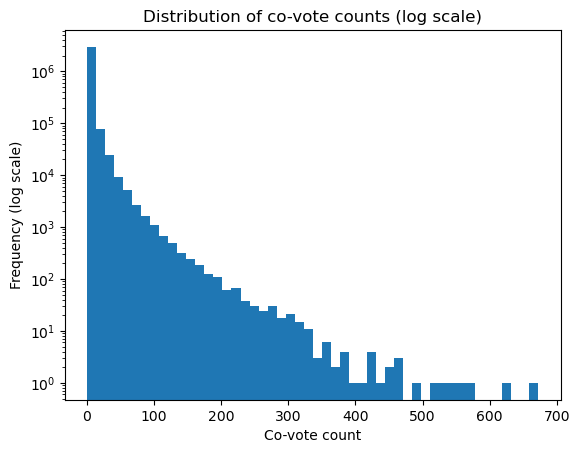

In [12]:
plt.hist(counts, bins=50, log=True)
plt.xlabel("Co-vote count")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of co-vote counts (log scale)")
plt.show()

In [13]:
import numpy as np

weights = np.array([d["normalized"] for _, _, d in G_proj.edges(data=True)])

print("Percentiles:")
for p in [50, 75, 80, 90, 95, 99]:
    print(f"{p}th percentile:", np.percentile(weights, p))

Percentiles:
50th percentile: 1.0
75th percentile: 1.0
80th percentile: 1.0
90th percentile: 1.0
95th percentile: 1.0
99th percentile: 1.0


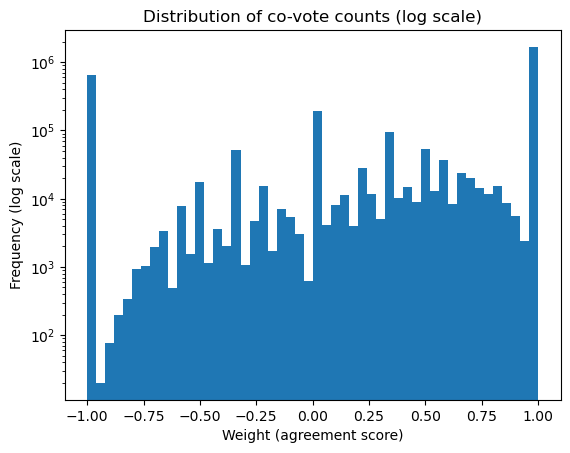

In [14]:
plt.hist(weights, bins=50, log=True)
plt.xlabel("Weight (agreement score)")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of co-vote counts (log scale)")
plt.show()

In [15]:
import networkx as nx

# Build two filtered graphs:
# - G_agree: edges with enough shared votes and mostly agreement
# - G_disagree: edges with enough shared votes and mostly disagreement

G_agree = nx.Graph()
G_disagree = nx.Graph()

for u, v, data in G_proj.edges(data=True):
    c = data["count"]
    n = data["normalized"]
    w = data["weight"]

    # Keep only edges with enough evidence
    if c < 4:
        continue

    # Agreement graph
    if n > 0:
        G_agree.add_edge(
            u,
            v,
            count=c,
            weight=w,
            normalized=n,
            community_weight=n
        )

    # Disagreement graph
    elif n < 0:
        G_disagree.add_edge(
            u,
            v,
            count=c,
            weight=abs(w),
            normalized=n,
            community_weight=abs(n)
        )

print("Agree graph:")
print("Nodes:", G_agree.number_of_nodes())
print("Edges:", G_agree.number_of_edges())

print("\nDisagree graph:")
print("Nodes:", G_disagree.number_of_nodes())
print("Edges:", G_disagree.number_of_edges())

Agree graph:
Nodes: 5182
Edges: 501024

Disagree graph:
Nodes: 4461
Edges: 106998


In [16]:
print("\nSample agree edges:")
print(list(G_agree.edges(data=True))[:5])

print("\nSample disagree edges:")
print(list(G_disagree.edges(data=True))[:5])


Sample agree edges:
[('INeverCry', 'Cncmaster', {'count': 11, 'weight': 11, 'normalized': 1.0, 'community_weight': 1.0}), ('INeverCry', 'Miniapolis', {'count': 22, 'weight': 18, 'normalized': 0.81818, 'community_weight': 0.81818}), ('INeverCry', 'Sven Manguard', {'count': 6, 'weight': 4, 'normalized': 0.66667, 'community_weight': 0.66667}), ('INeverCry', 'RockMagnetist', {'count': 4, 'weight': 4, 'normalized': 1.0, 'community_weight': 1.0}), ('INeverCry', 'Carrite', {'count': 19, 'weight': 15, 'normalized': 0.78947, 'community_weight': 0.78947})]

Sample disagree edges:
[('INeverCry', 'Colonel Warden', {'count': 15, 'weight': 5, 'normalized': -0.33333, 'community_weight': 0.33333}), ('INeverCry', 'John', {'count': 8, 'weight': 4, 'normalized': -0.5, 'community_weight': 0.5}), ('INeverCry', 'Intothatdarkness', {'count': 9, 'weight': 3, 'normalized': -0.33333, 'community_weight': 0.33333}), ('INeverCry', 'WilyD', {'count': 6, 'weight': 2, 'normalized': -0.33333, 'community_weight': 0.33

In [17]:
data = json_graph.node_link_data(G_agree)

with open("rfa_projected_graph_agree.json", "w", encoding="utf-8") as f:
    json.dump(data, f)

In [18]:
data = json_graph.node_link_data(G_disagree)

with open("rfa_projected_graph_disagree.json", "w", encoding="utf-8") as f:
    json.dump(data, f)